In [1]:
from pathlib import Path
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'MPMs').is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
import os
os.environ['JAX_PLATFORMS'] = 'cpu'
import importlib
import equinox as eqx
import jax.numpy as jnp
import jax
import diffrax as dfx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import MPMs.DATA_functions_01 as DF
import MPMs.UTIL_functions_01 as UF
import MPMs.ANA_functions_02 as AF
import MPMs.MPM_functions_07 as MF
import MPMs.HELPER_functions_02 as HF

importlib.reload(HF)
importlib.reload(MF)
importlib.reload(UF)
importlib.reload(DF)
importlib.reload(AF);

# Cross Validation

## Compare Versions

In [2]:
importlib.reload(AF)
importlib.reload(UF)

versions = []
not_found = []
for nr in [3]:
    nr = f"{nr:02.0f}"
    for let in "ACD":
        version = f"SLIM_{nr}{let}"
        id = "_sc"
        filepath = f"{REPO_ROOT}/slim_model_data/{version}/analysis{id}.pkl"
        if not os.path.isfile(filepath):
            # print(version, "not found")
            not_found.append(version)
        else:
            versions.append(version)

# versions = ["MPM_41H","MPM_42H","MPM_43H"] + versions

print("NOT FOUND:",not_found)
metrics = ["R2","NMAE"]
_ = AF.NEW_compare_versions(versions,
                            # last_model=False,     # bool, default = True
                            # equal_comparison=False, # bool, default = True
                            metrics=metrics,
                            )
METRIC_values, labels = _

NOT FOUND: []
Last Model       : True
Equal Comparison : True
--- R2   ---
                          | avg(GPX) | avg(PX)  | G        | P        | X        | V        | P/X      | 
---------------------------------------------------------------------------------------------------------
                 SLIM_03A |      inf |   0.9633 |      inf |   0.9827 |   0.9439 |   1.0000 |   0.9266 |  NO; incomplete (9 processes)
                 SLIM_03C |      inf |   0.9595 |      inf |   0.9686 |   0.9504 |   1.0000 |   0.8571 |  NN; incomplete (9 processes)
                 SLIM_03D |      inf |   0.8553 |      inf |   0.9481 |   0.7626 |   1.0000 |   0.2610 |  unknown; incomplete (9 processes)
--- NMAE ---
                          | avg(GPX) | avg(PX)  | G        | P        | X        | V        | P/X      | 
---------------------------------------------------------------------------------------------------------
                 SLIM_03A |      inf |   0.0663 |      inf |   0.0613 |   0.07

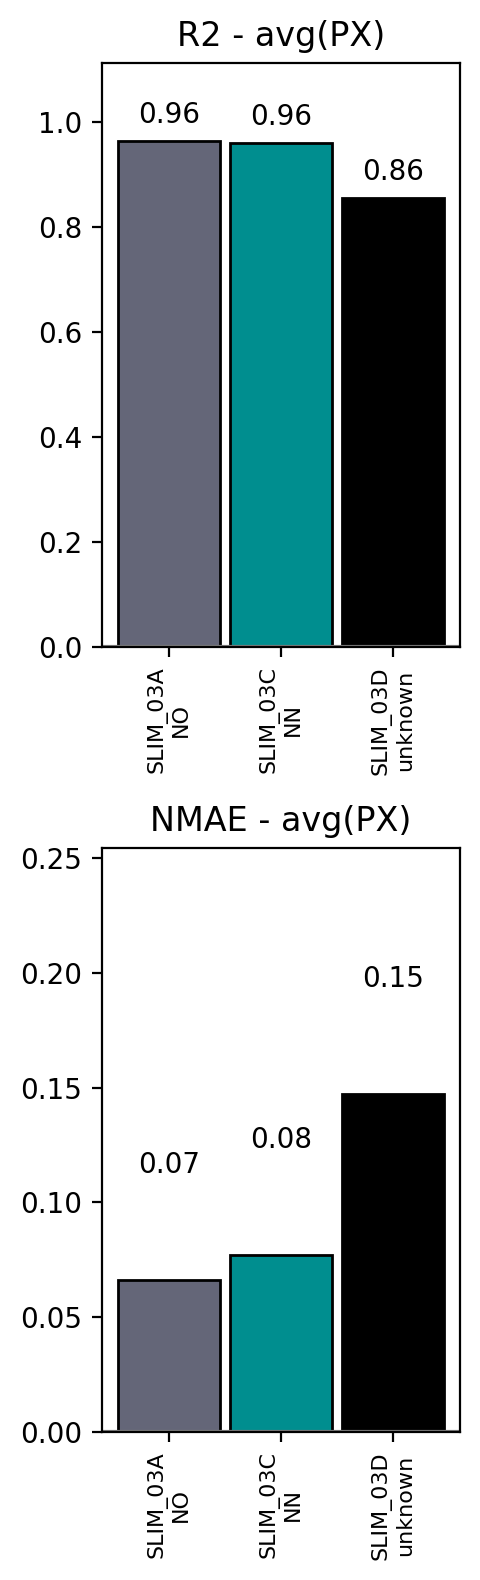

In [3]:
importlib.reload(AF)
METRIC_index = 1
suptitle = labels[METRIC_index]
AF.plot_compare_versions(versions, metrics, METRIC_values, 
                         METRIC_index=METRIC_index, 
                         suptitle=suptitle)

# Generate Ensemble Model

In [4]:
if "MM" in vars():
    del MM

#--- INPUTs ---#
version = "SLIM_03C"
base_path = f"{REPO_ROOT}/slim_model_scripts/"
model_path = f"{base_path}/{version}.py"
#--------------#

MM = UF.import_module_from_path(model_path)
exp_dataframes = MM.get_exp_dfs()
aug_dataframes = MM.get_aug_dfs()
cross_valid_sets = MM.HF.SLIM_get_valid_sets()
scalers, ALL_kwargs = MM.get_model_config()

#-------------------- CONFIG --------------------#
fba_type          : SRfba
base_flux_type    : none
LIM_handler_type  : fixed
modify_ann_inp    : none
extra_metabolites : True
#------------------------------------------------#


In [5]:
print("load DATA")
EXP_DATA_process_names = [f"exp{i}" for i in range(1,10)]
EXP_DATA = DF.PRE_process_data_SLIM_ALL(exp_dataframes,scalers,
                            EXP_DATA_process_names,
                            inverse=True,
                            yi_method="copy",
                            Ycols=["G","P","X","V_N"],
                            Ucols=["t","Cf_N","G_Cf"],
                            verbose=True)
    
ctrl_idx = jnp.isclose(EXP_DATA[5][:,0,-1],14.606/.5)
slim_idx = jnp.invert(ctrl_idx)
print(ctrl_idx)
print(slim_idx)

load DATA
off: (63, 6), onl: (189, 6), dsp: (9, 2)
off: (63, 6), onl: (189, 6), dsp: (9, 2)
YY: (9, 7, 4) YT: (9, 7, 1) UU: (9, 21, 3) UT: (9, 21, 1) DS: (9, 1, 1)
yy: (9, 7, 4) uu: (9, 21, 3)
uc: (9, 4, 20, 3)
yi: (9, 1, 8)
[ True False False False  True  True False False False]
[False  True  True  True False False  True  True  True]


In [6]:
versions = ['SLIM_03A', 'SLIM_03Ai', "SLIM_03C" , 'SLIM_03C/ANN2SR_03']

ENS_models = {}
for version in versions: 
    print(version)
    if "MM" in vars():
        del MM

    # get model configs and scalers
    base_path = f"{REPO_ROOT}/slim_model_scripts/"
    model_path = f"{base_path}/{version.split('/')[0]}.py"
    MM = UF.import_module_from_path(model_path)
    cross_valid_sets = MM.HF.SLIM_get_valid_sets()
    scalers, ALL_kwargs = MM.get_model_config(verbose=False)

    models = []
    for set_index in range(len(cross_valid_sets)):
        ODE_kwargs, TRAIN_kwargs = ALL_kwargs
        ODE_kwargs["verbose"] = False
        model = MM.ODE(**ODE_kwargs)
        model = eqx.nn.inference_mode(model)

        if "ANN2SR" in version:
            model = HF.PYSR_model_loader(
                mpm_version = version.split("/")[0],
                pysr_version = version.split("/")[1],
                dataset_name = "slim",
                base_model = model,
                set_name = f"set_{set_index+1}",
            )
        else:
            weights_path = model_path.replace("model_scripts","model_data").replace(".py",f"/set_{set_index+1}_last.eqx")
            model = eqx.tree_deserialise_leaves(weights_path, model)
            model = eqx.nn.inference_mode(model)
        models.append(model)
    # build an ensemble model from CV models
    ENS_model = MF.Ensemble(models)
    ENS_models[version] = ENS_model
    # break
print("DONE")

SLIM_03A
SLIM_03Ai
SLIM_03C
SLIM_03C/ANN2SR_03
Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


Attempting to load model from /home/mgotsmy/code/260421_fba_hyb/FBA-Hyb/slim_model_data/SLIM_03C/ANN2SR_03/set_1/checkpoint.pkl...
Attempting to load model from /home/mgotsmy/code/260421_fba_hyb/FBA-Hyb/slim_model_data/SLIM_03C/ANN2SR_03/set_2/checkpoint.pkl...
Attempting to load model from /home/mgotsmy/code/260421_fba_hyb/FBA-Hyb/slim_model_data/SLIM_03C/ANN2SR_03/set_3/checkpoint.pkl...
Attempting to load model from /home/mgotsmy/code/260421_fba_hyb/FBA-Hyb/slim_model_data/SLIM_03C/ANN2SR_03/set_4/checkpoint.pkl...
Attempting to load model from /home/mgotsmy/code/260421_fba_hyb/FBA-Hyb/slim_model_data/SLIM_03C/ANN2SR_03/set_5/checkpoint.pkl...
Attempting to load model from /home/mgotsmy/code/260421_fba_hyb/FBA-Hyb/slim_model_data/SLIM_03C/ANN2SR_03/set_6/checkpoint.pkl...
Attempting to load model from /home/mgotsmy/code/260421_fba_hyb/FBA-Hyb/slim_model_data/SLIM_03C/ANN2SR_03/set_7/checkpoint.pkl...
Attempting to load model from /home/mgotsmy/code/260421_fba_hyb/FBA-Hyb/slim_model_

DONE


In [7]:
key = jax.random.PRNGKey(13)

print("ENSEMBLE MODELS METRICS")
metrics = ["R2","NMAE"]
for metric in metrics:
    print(f"--- {metric} ---")
    count = 0
    for version, SRfba_ENS in ENS_models.items():
        count += 1
        
        list_YY_true = []
        list_YY_pred = []
        # for i, data in enumerate(DATA):
        for i in range(EXP_DATA[0].shape[0]):
            data = [_[i:i+1] for _ in EXP_DATA]
            yy_true = data[0]
            YT, yy_pred = AF.parse_data_to_model(SRfba_ENS, data, key)
            # print(yy_pred.shape)
            # yy_pred = jnp.mean(yy_pred,axis=1)
            YY_true = SRfba_ENS.models[0].HYB.SCL_yy.unscale(yy_true)
            YY_pred = SRfba_ENS.models[0].HYB.SCL_yy.unscale(yy_pred[:,:,:SRfba_ENS.models[0].HYB.NR_state_variables])
            # AF.NEW_print_stats((YY_true, YY_pred), f"ensemble 121B set {i+1}", header=i==0,verbose=True,metric=metric)
            list_YY_true.append(YY_true)
            list_YY_pred.append(YY_pred)
            # break
        list_YY_true = jnp.concatenate(list_YY_true,axis=0)
        list_YY_pred = jnp.concatenate(list_YY_pred,axis=0)
        AF.NEW_print_stats((list_YY_true, list_YY_pred), 
                           f"ENS {version}", 
                           header=count==1,verbose=True,metric=metric)


ENSEMBLE MODELS METRICS
--- R2 ---
                          | avg(GPX) | avg(PX)  | G        | P        | X        | V        | P/X      | 
---------------------------------------------------------------------------------------------------------
             ENS SLIM_03A |      inf |   0.9736 |      inf |   0.9859 |   0.9613 |   1.0000 |   0.9536 |  
            ENS SLIM_03Ai |      inf |   0.9676 |      inf |   0.9863 |   0.9489 |   1.0000 |   0.9450 |  
             ENS SLIM_03C |      inf |   0.9723 |      inf |   0.9764 |   0.9682 |   1.0000 |   0.8851 |  
   ENS SLIM_03C/ANN2SR_03 |      inf |   0.9724 |      inf |   0.9758 |   0.9690 |   1.0000 |   0.8867 |  
--- NMAE ---
                          | avg(GPX) | avg(PX)  | G        | P        | X        | V        | P/X      | 
---------------------------------------------------------------------------------------------------------
             ENS SLIM_03A |      inf |   0.0558 |      inf |   0.0530 |   0.0586 |   0.0000 |   0.09

# Figure SLIM Optimization

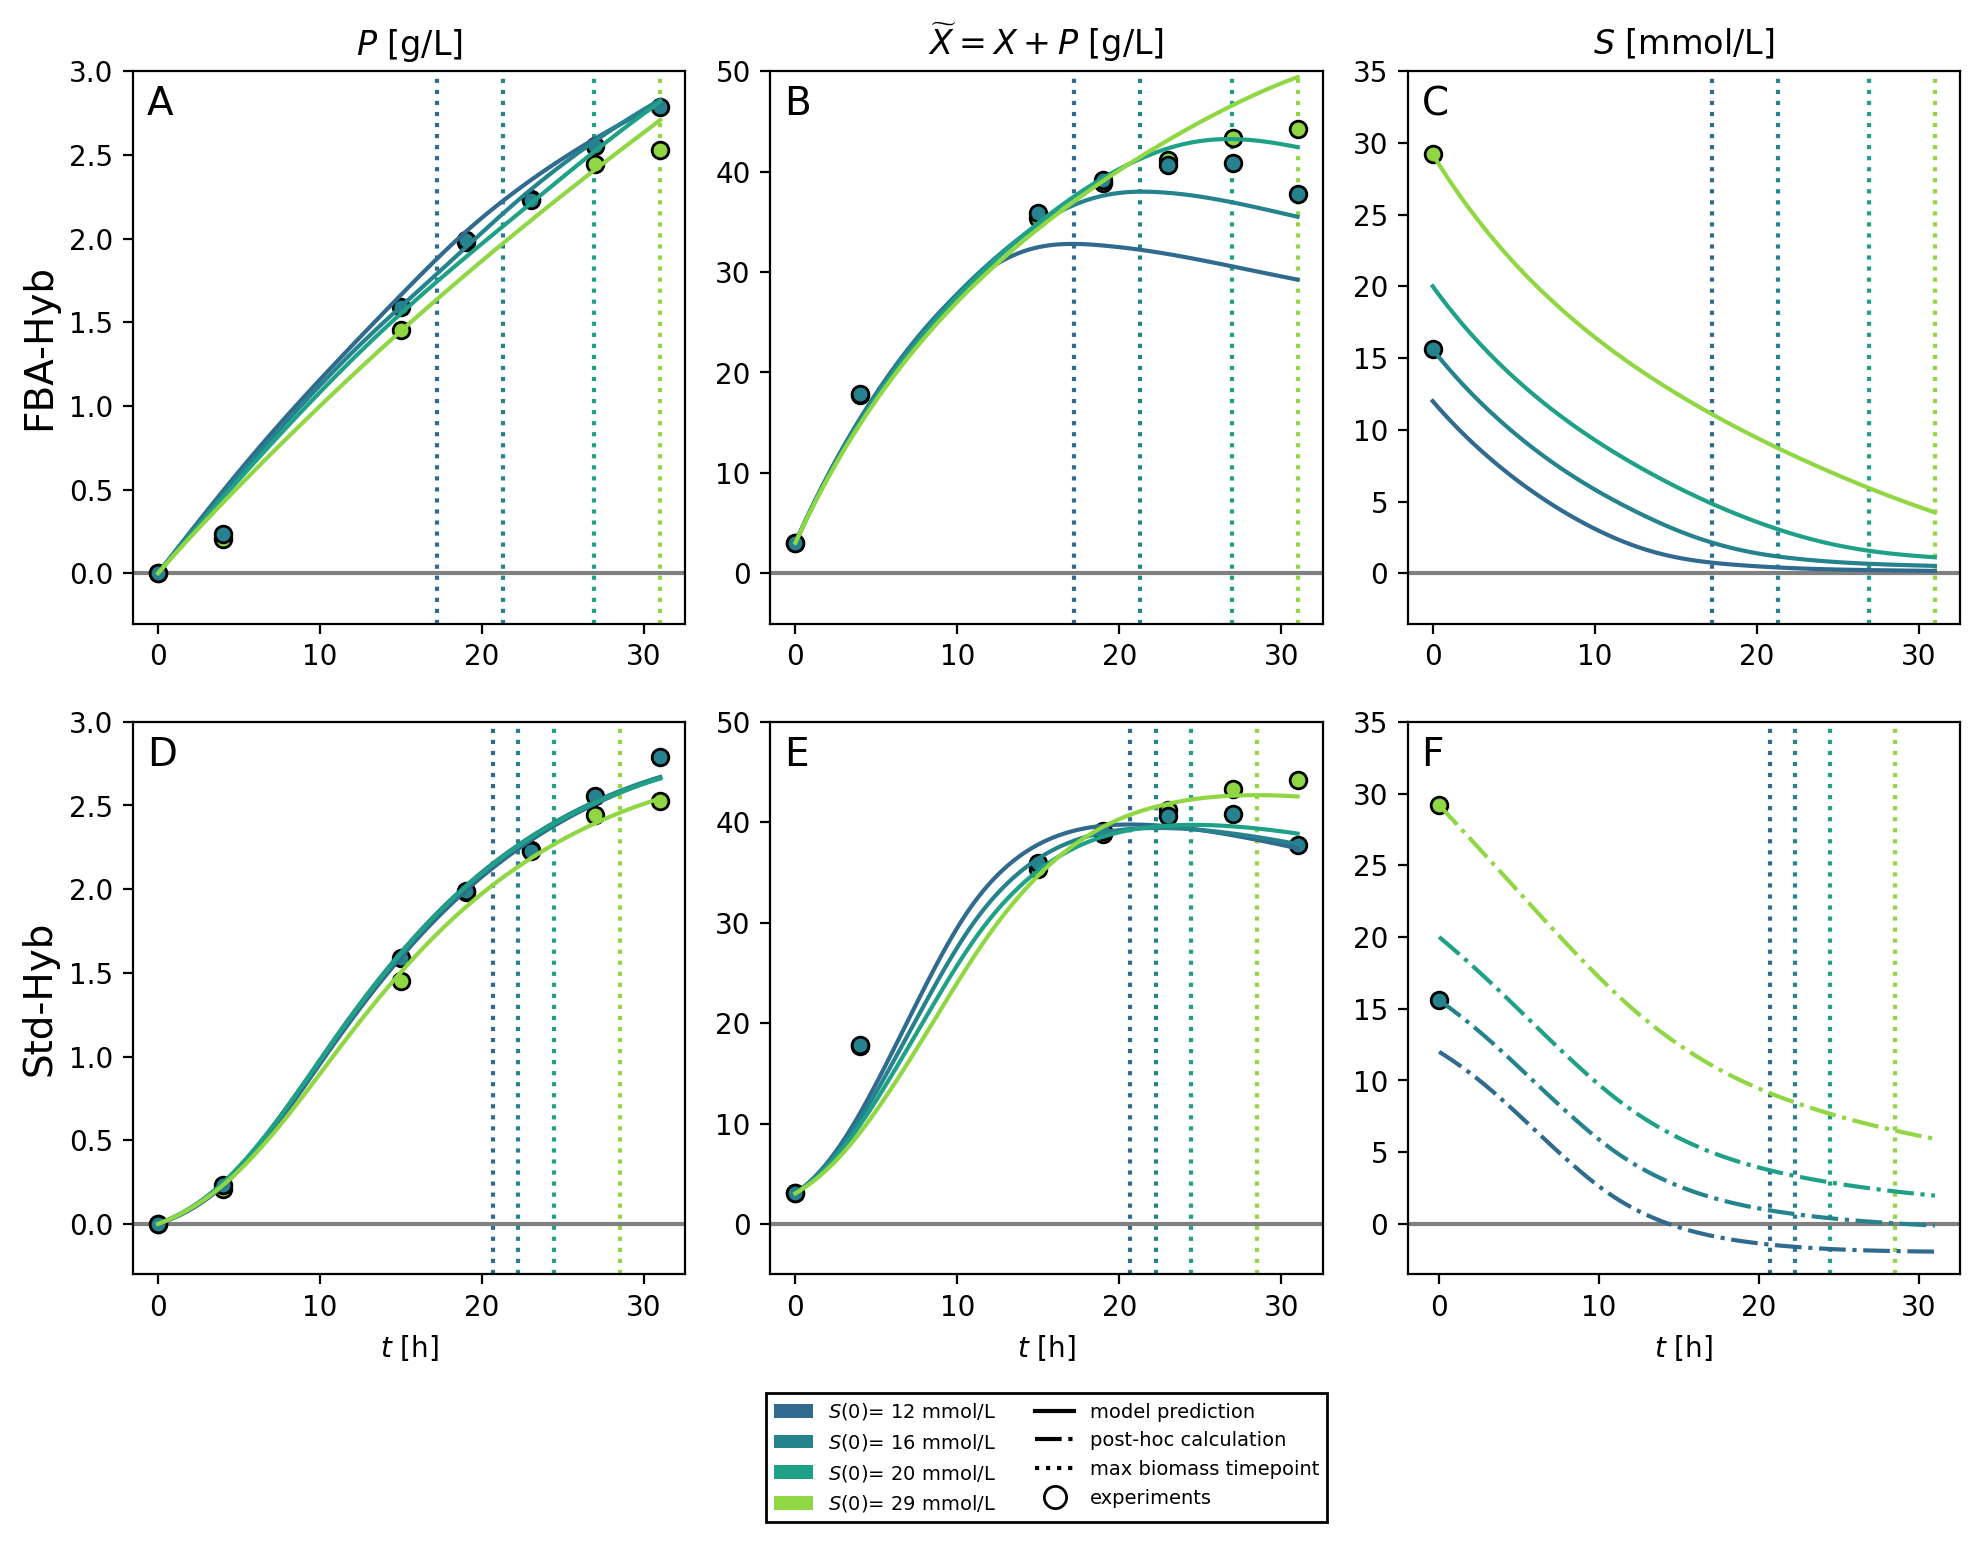

In [8]:
key = jax.random.PRNGKey(13)

SRfba_ENS = ENS_models["SLIM_03C"]
SRfba_TMP = SRfba_ENS.models[0]

NOfba_ENS = ENS_models["SLIM_03Ai"]
NOfba_TMP = NOfba_ENS.models[0]

def get_color(x):
    return mpl.colormaps["viridis"](x/35)

# Changed figsize from (5,8) to (8,5) for horizontal layout
fig = plt.figure(dpi=200, figsize=(10,8))

# Changed from 3x2 to 2x3 layout
ax1a = plt.subplot(231,box_aspect=1)  # row 1, col 1
ax2a = plt.subplot(232,box_aspect=1)  # row 1, col 2  
ax3a = plt.subplot(233,box_aspect=1)  # row 1, col 3
ax1b = plt.subplot(234,box_aspect=1)  # row 2, col 1
ax2b = plt.subplot(235,box_aspect=1)  # row 2, col 2
ax3b = plt.subplot(236,box_aspect=1)  # row 2, col 3

adds = np.array([6,7.8,10,14.6])*2
j = 0
for l, add in enumerate(adds):
    data_ = [_[j:j+1] for _ in EXP_DATA]
    data_[5] = data_[5].at[0, 0, -1].set(add)  # subtract 10
    YT, yy_pred = AF.parse_data_to_model(SRfba_ENS, data_,key,timepoints=100)
    label = r"SO$_4^{2-}$ ="+f" {data_[5][0,0,-1]:.0f} mmol/L"
    color = get_color(add)

    YY_pred = SRfba_ENS.models[0].HYB.SCL_yy.unscale(yy_pred[0,:,:4]) 
    ax3a.plot(YT[0],yy_pred[0,:,-1],color=color)
    ax2a.plot(YT[0],YY_pred[:,2]   ,color=color)
    ax1a.plot(YT[0],YY_pred[:,1]   ,color=color)

    for ax in [ax1a,ax2a,ax3a]:
        ax.axvline(YT[0][np.argmax(YY_pred[:,2])], color=color, linestyle=":", zorder=-1)

for l, add in enumerate(adds):
    data_ = [_[j:j+1] for _ in EXP_DATA]
    data_[5] = data_[5].at[0, 0, -1].set(add)
    YT, yy_pred = AF.parse_data_to_model(NOfba_ENS, data_,key,timepoints=100)
    label = r"SO$_4^{2-}$ ="+f" {data_[5][0,0,-1]:.0f} mmol/L"
    color = get_color(add)

    YY_pred = NOfba_ENS.models[0].HYB.SCL_yy.unscale(yy_pred[0,:,:4]) 
    XV = YY_pred[:,2]*YY_pred[:,3]
    PV = YY_pred[:,1]*YY_pred[:,3]
    # growth of Xr (active biomass, i.e., biomass minus pDNA)
    dXV = (XV-PV)-(XV[0]-PV[0])
    S_consumed = dXV*0.2518200000000 # mmol
    S_conc = (data_[5][0,0,-1]*YY_pred[0,3] - S_consumed)/YY_pred[:,3]
    ax3b.plot(YT[0],S_conc,color=color,linestyle="-.")

    ax2b.plot(YT[0],YY_pred[:,2]   ,color=color)
    ax1b.plot(YT[0],YY_pred[:,1]   ,color=color)
    
    ax3b.axvline(YT[0][np.argmax(YY_pred[:,2])], color=color, linestyle=":", zorder=-1)
    ax2b.axvline(YT[0][np.argmax(YY_pred[:,2])], color=color, linestyle=":", zorder=-1)
    ax1b.axvline(YT[0][np.argmax(YY_pred[:,2])], color=color, linestyle=":", zorder=-1)

for axA, axB, lb, ub in zip([ax1a,ax2a,ax3a],[ax1b,ax2b,ax3b],[-3/10,-50/10,-35/10],[3,50,35]):
    axA.set_ylim(lb,ub)
    axB.set_ylim(lb,ub)
    axA.axhline( 0,color="grey", linestyle="-", zorder=-1)
    axB.axhline( 0,color="grey", linestyle="-", zorder=-1)

plot_real_data = True
if plot_real_data:
    YT = EXP_DATA[1]
    YY_TRUE = SRfba_ENS.models[0].HYB.SCL_yy.unscale(EXP_DATA[0])

    YY_CTRL = np.mean(YY_TRUE[ctrl_idx,:,:],axis=0)
    YT_CTRL = np.mean(YT[ctrl_idx,:,0],axis=0)
    ax1a.scatter(YT_CTRL,YY_CTRL[:,1],edgecolor="k",color=get_color(14.606/.5))
    ax1b.scatter(YT_CTRL,YY_CTRL[:,1],edgecolor="k",color=get_color(14.606/.5))
    ax2a.scatter(YT_CTRL,YY_CTRL[:,2],edgecolor="k",color=get_color(14.606/.5))
    ax2b.scatter(YT_CTRL,YY_CTRL[:,2],edgecolor="k",color=get_color(14.606/.5))

    YY_SLIM = np.mean(YY_TRUE[slim_idx,:,:],axis=0)
    YT_SLIM = np.mean(YT[slim_idx,:,0],axis=0)
    ax1a.scatter(YT_SLIM,YY_SLIM[:,1],edgecolor="k",color=get_color(7.7899/.5))
    ax1b.scatter(YT_SLIM,YY_SLIM[:,1],edgecolor="k",color=get_color(7.7899/.5))
    ax2a.scatter(YT_SLIM,YY_SLIM[:,2],edgecolor="k",color=get_color(7.7899/.5))
    ax2b.scatter(YT_SLIM,YY_SLIM[:,2],edgecolor="k",color=get_color(7.7899/.5))

ax1a.set_ylabel("FBA-Hyb",fontsize=14)
ax1b.set_ylabel("Std-Hyb",fontsize=14)
titles = [r"$P$ [g/L]",r"$\widetilde{X}=X+P$ [g/L]",r"$S$ [mmol/L]"]
for ax,title in zip([ax1a,ax2a,ax3a],titles):
    ax.set_title(title,fontsize=12)

ax2b.set_xlabel("$t$ [h]")
ax3b.set_xlabel("$t$ [h]")
ax1b.set_xlabel("$t$ [h]")

for s0 in [7.8, 14.6]:
    ax3b.scatter(0,s0/.5,edgecolor="k",color=get_color(s0/.5))
    ax3a.scatter(0,s0/.5,edgecolor="k",color=get_color(s0/.5))

plot_legend = True
if plot_legend:
    # Create legend with 2 columns - all elements listed sequentially
    legend_elements = []

    # Add SO4 concentrations
    for add in adds:
        color = get_color(add)
        label = r"$S(0)$= " + f"{add:.0f} mmol/L"
        legend_elements.append(plt.bar([0], [0], color=color, linewidth=5, label=label))

    # Add line style explanations
    # legend_elements.append(plt.Line2D([0], [0], color='white', linestyle='-', label=''))
    legend_elements.append(plt.Line2D([0], [0], color='black', linestyle='-', label='model prediction'))
    legend_elements.append(plt.Line2D([0], [0], color='black', linestyle='-.', label='post-hoc calculation'))
    legend_elements.append(plt.Line2D([0], [0], color='black', linestyle=':', label='max biomass timepoint'))

    # Add scatter point explanations
    legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor="w", 
                                    markeredgecolor='k', markersize=8, label= "experiments", linestyle='None'))

    # Place legend at the bottom of the figure with 2 columns
    fig.tight_layout()
    ax1_pos = ax1b.get_position()
    ax2_pos = ax3b.get_position()
    legend_x = (ax1_pos.x0 + ax2_pos.x1) / 2
    fig.legend(handles=legend_elements, loc="center", bbox_to_anchor=(legend_x, .05), ncol=2, 
            frameon=True, fancybox=False, shadow=False, columnspacing=2.0,fontsize=7,framealpha=1,edgecolor="black")

import matplotlib.transforms as mtransforms
for name, ax in zip(['A','B','C','D','E','F'],[ax1a,ax2a,ax3a,ax1b,ax2b,ax3b]):
    trans = mtransforms.ScaledTranslation(5/72, -5/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, name, transform=ax.transAxes + trans,
    fontsize=14, verticalalignment='top', fontfamily='sans',
    bbox=dict(facecolor='none', edgecolor='none', pad=3.0))

# Adjust layout to make room for legend
fig.tight_layout()
# fig.align_labels()
plt.subplots_adjust(bottom=0.1)
plt.show()

# Figure n and q

In [9]:
TMP_ENS = ENS_models["SLIM_03C"]

add = 14.6*2
add = 7.8 *2
data_ = [_[j:j+1] for _ in EXP_DATA]
data_[5] = data_[5].at[0, 0, -1].set(add)
YT, yy_pred = AF.parse_data_to_model(TMP_ENS, data_,key,timepoints=100)

TRUE = AF.NEW_get_predictions(TMP_ENS, data_, key, mode="true")
PRED = AF.NEW_get_predictions(TMP_ENS, data_, key, mode="pred")
SMTH = AF.NEW_get_predictions(TMP_ENS, data_, key, mode="smth")

(7,) (7, 5)
(7,) (7, 5)
(1000,) (1000, 5)


In [10]:
def normizer(a):
        a = jnp.abs(a)
        s = jnp.sum(a)+1e-8
        return a/s

def multiply_by_qGqI(a):
      # biomass, pDNA, atpm 
      # mol G per mol
      s = jnp.array([11.07662203125002,31.50551020408157,0.04255319148936006])
      return a * s

SCL_n = DF.SCL_init_from_slim_fba(["nr_X","nr_P","nr_M"],"mean")
FBA_inp = SMTH["FBA_inp"] # qG, nX, nP, nM

# these are scaled values are already averaged
n = FBA_inp[0,:,1:4]
# first we want them to add up to 1
n = jax.vmap(normizer)(n)
# then unscale
n = SCL_n.unscale(n)
# then multiply by the qG/qI ratios to get qG-equivalents
n = jax.vmap(multiply_by_qGqI)(n)
n = jax.vmap(normizer)(n)
print(FBA_inp.shape)
# print(FBA_inp_avg.shape)    
print(n.shape)

qG = SMTH["V_out"][0,:,0]
q = jax.vmap(multiply_by_qGqI)(jnp.take(SMTH["V_out"][0,:,:],jnp.array([2,1,3]),axis=1))

(1, 1000, 4)
(1000, 3)


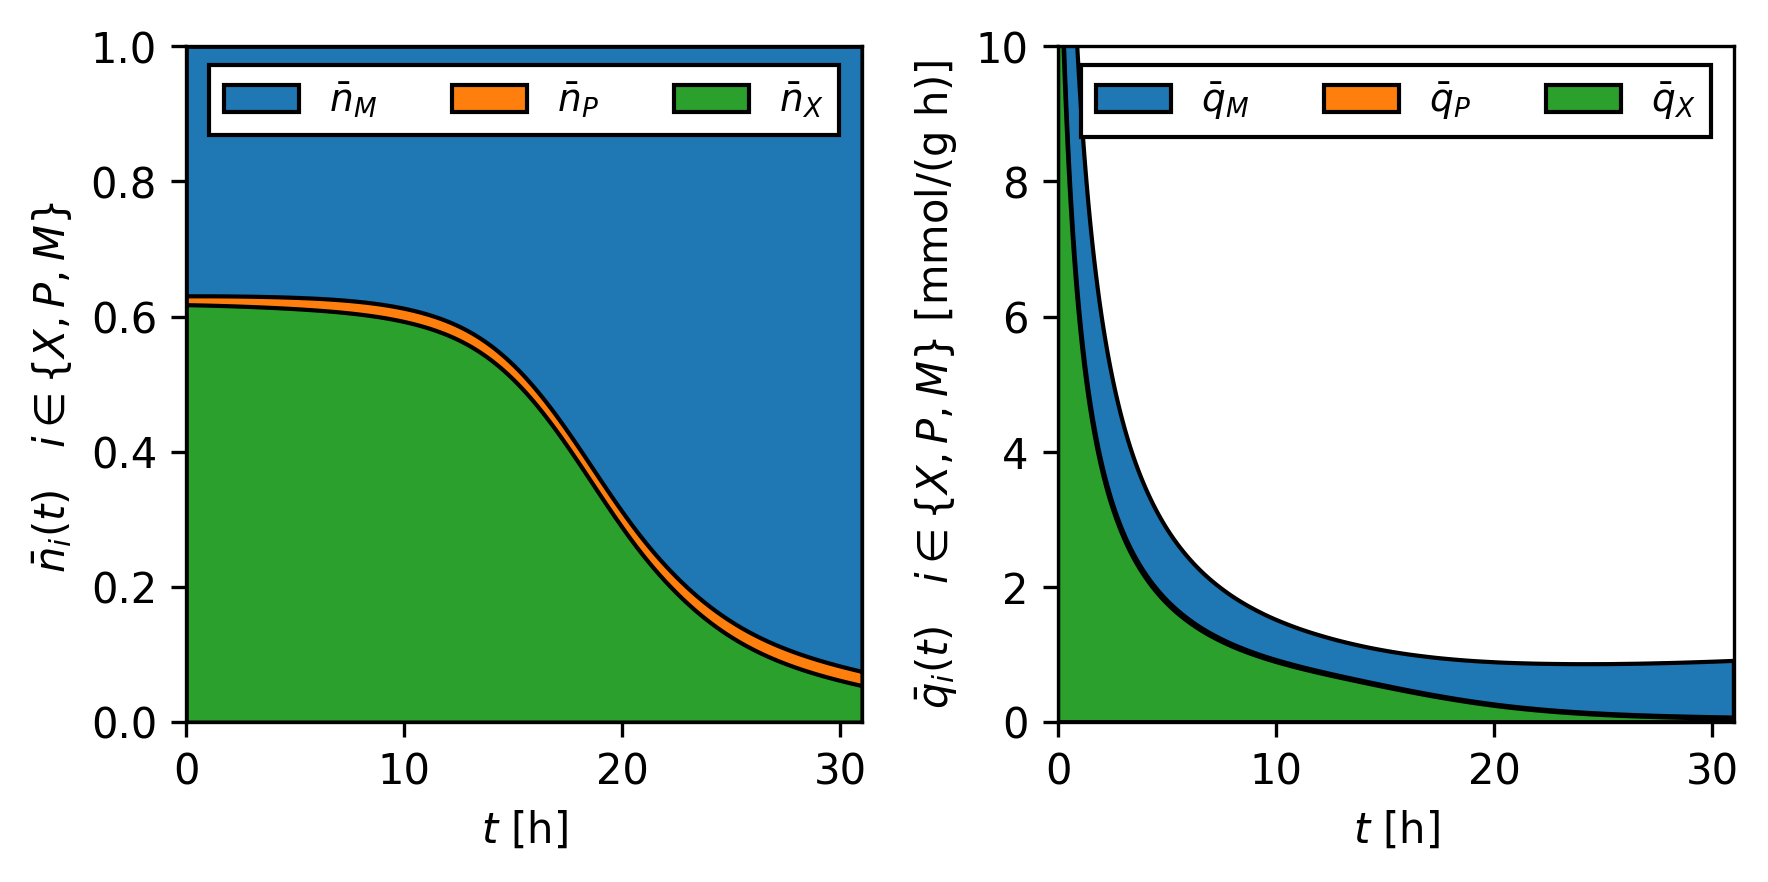

In [11]:
plt.figure(dpi=300, figsize=(6, 4))
tt = SMTH["t"][0,:]

ax1 = plt.subplot(121, box_aspect=1)

plt.fill_between(tt,n[:,2]+n[:,0]+n[:,1],label=r"$\bar{n}_M$",edgecolor="k")
plt.fill_between(tt,n[:,1]+n[:,0],label=r"$\bar{n}_P$",edgecolor="k")
plt.fill_between(tt,n[:,0],label=r"$\bar{n}_X$",edgecolor="k")
# plt.plot(tt,n[:,2],label=r"$\bar{n}_M$")
# plt.plot(tt,n[:,1],label=r"$\bar{n}_P$")
# plt.plot(tt,n[:,0],label=r"$\bar{n}_X$")


plt.ylim(0,1)
plt.ylabel(r"$\bar{n}_i(t) \quad i \in \{X, P, M\}$ ")
plt.legend(fancybox=False,framealpha=1,edgecolor="k",loc="upper center",ncol=3,fontsize=9)

ax2 = plt.subplot(122, box_aspect=1)
# plt.plot(tt,qG,label="qG",color="k")
# plt.plot(q[:,0],label="X")
# plt.plot(q[:,1],label="P")
# plt.plot(q[:,2],label="M")
plt.fill_between(tt,q[:,2]+q[:,0]+q[:,1],label=r"$\bar{q}_M$",edgecolor="k")
plt.fill_between(tt,q[:,1]+q[:,0],label=r"$\bar{q}_P$",edgecolor="k")
plt.fill_between(tt,q[:,0],label=r"$\bar{q}_X$",edgecolor="k")
# plt.plot(tt,jnp.sum(q,axis=1),ls="--",label="q_total") # sanity check. works
plt.ylabel(r"$\bar{q}_i(t) \quad i \in \{X, P, M\}$ [mmol/(g h)]")
plt.ylim(0,10)
# plt.yticks([0,5,10,15,20])
plt.legend(fancybox=False,framealpha=1,edgecolor="k",loc="upper center",ncol=3,fontsize=9)

for ax in [ax1,ax2]:
    ax.set_xlim(tt[0],tt[-1])
    ax.set_xlabel(r"$t$ [h]")
plt.tight_layout()
plt.show()

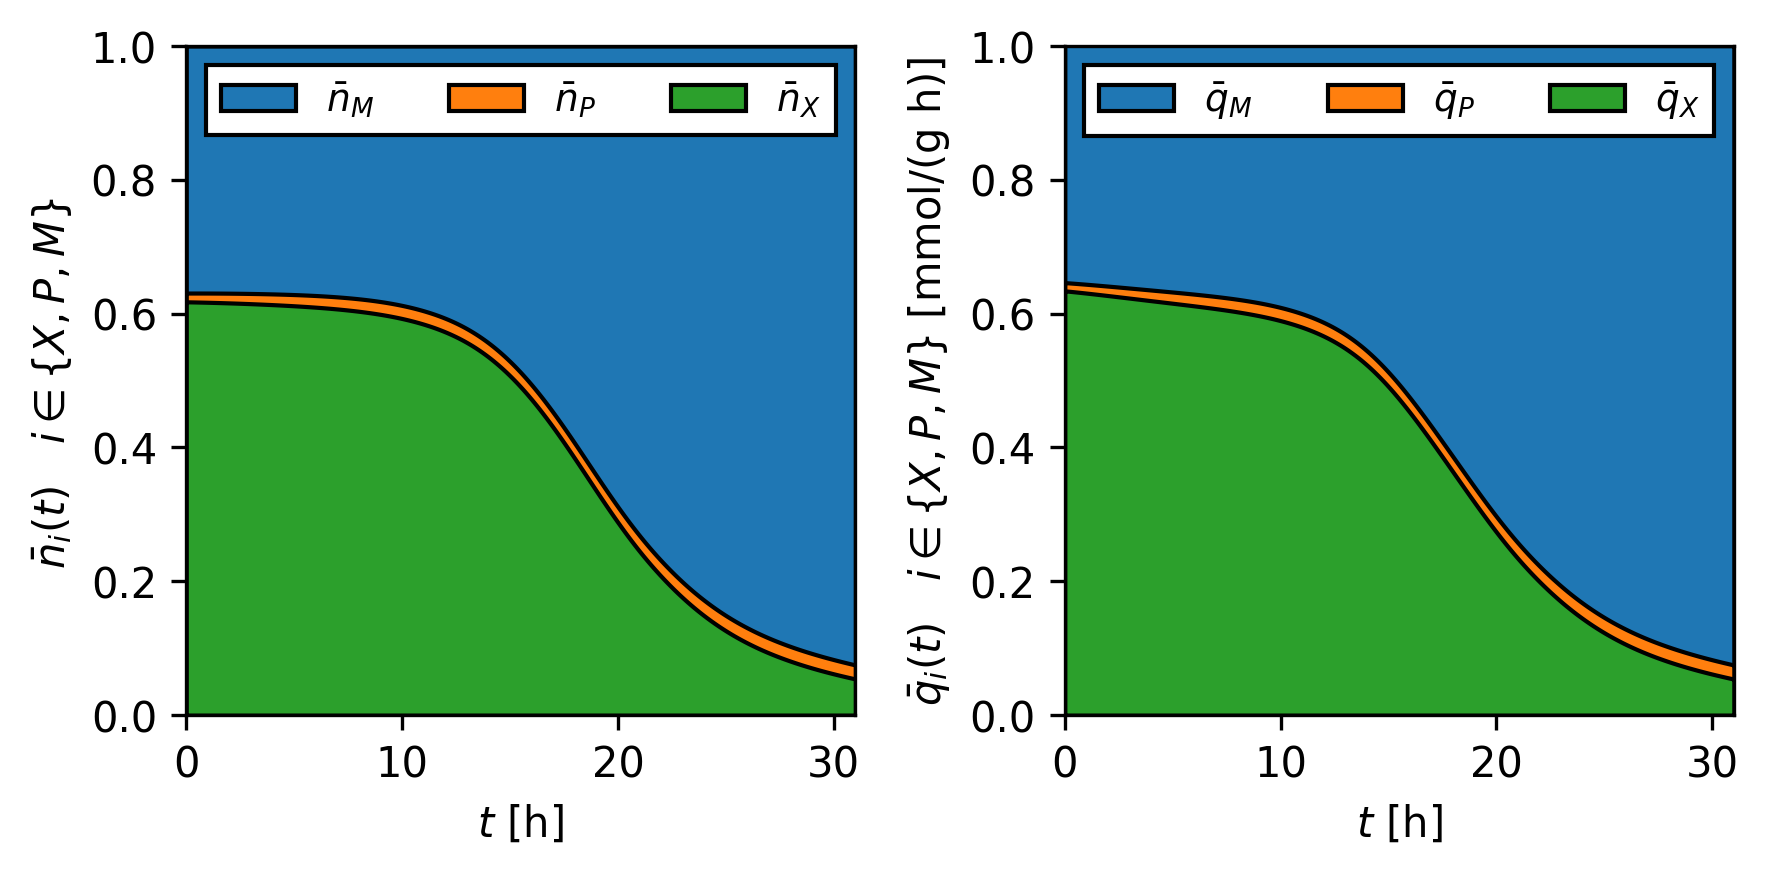

In [12]:
plt.figure(dpi=300, figsize=(6, 4))
tt = SMTH["t"][0,:]

ax1 = plt.subplot(121, box_aspect=1)

plt.fill_between(tt,n[:,2]+n[:,0]+n[:,1],label=r"$\bar{n}_M$",edgecolor="k")
plt.fill_between(tt,n[:,1]+n[:,0],label=r"$\bar{n}_P$",edgecolor="k")
plt.fill_between(tt,n[:,0],label=r"$\bar{n}_X$",edgecolor="k")
plt.ylim(0,1)
plt.ylabel(r"$\bar{n}_i(t) \quad i \in \{X, P, M\}$ ")
plt.legend(fancybox=False,framealpha=1,edgecolor="k",loc="upper center",ncol=3,fontsize=9)

ax2 = plt.subplot(122, box_aspect=1)
plt.fill_between(tt,(q[:,2]+q[:,0]+q[:,1])/qG,label=r"$\bar{q}_M$",edgecolor="k")
plt.fill_between(tt,(q[:,1]+q[:,0]       )/qG,label=r"$\bar{q}_P$",edgecolor="k")
plt.fill_between(tt,(q[:,0]              )/qG,label=r"$\bar{q}_X$",edgecolor="k")
plt.ylabel(r"$\bar{q}_i(t) \quad i \in \{X, P, M\}$ [mmol/(g h)]")
plt.ylim(0,1)
plt.legend(fancybox=False,framealpha=1,edgecolor="k",loc="upper center",ncol=3,fontsize=9)

for ax in [ax1,ax2]:
    ax.set_xlim(tt[0],tt[-1])
    ax.set_xlabel(r"$t$ [h]")
plt.tight_layout()
plt.show()

# GA Figure - SLIM in the Middle

21.292929


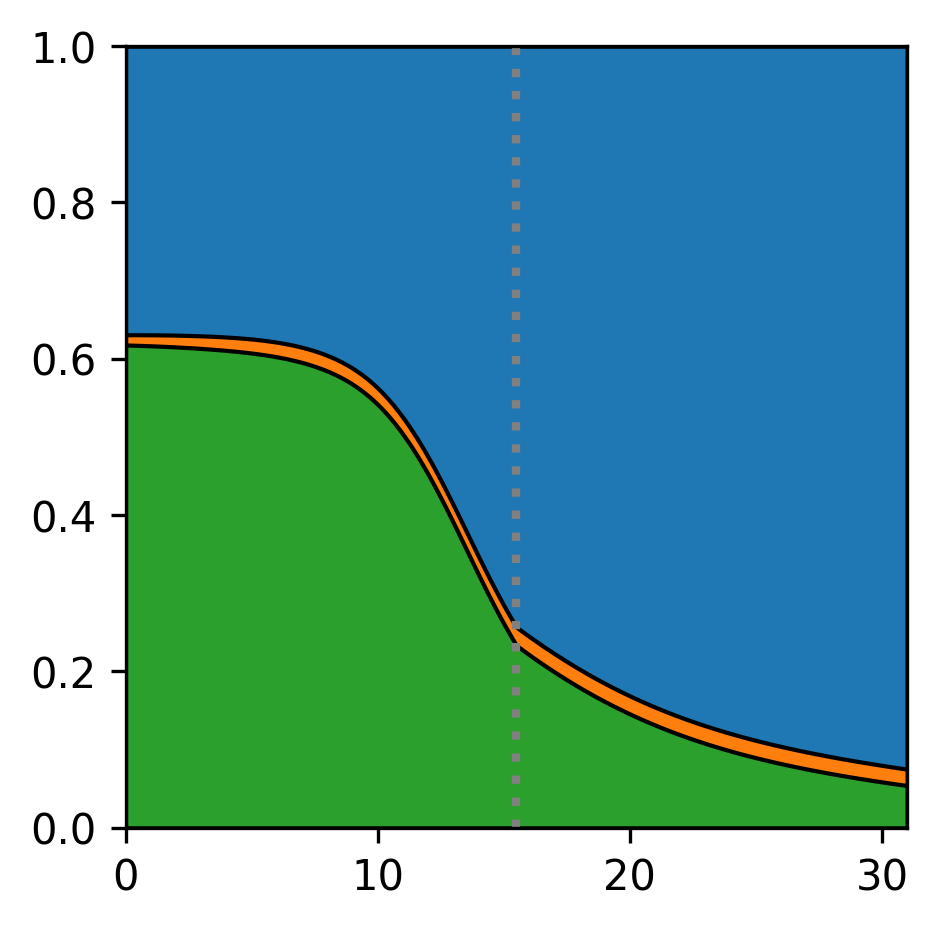

In [13]:
j = 0
add = 7.8*2
data_ = [_[j:j+1] for _ in EXP_DATA]
data_[5] = data_[5].at[0, 0, -1].set(add)  # subtract 10
YT, yy_pred = AF.parse_data_to_model(SRfba_ENS, data_,key,timepoints=100)
T_X_MAX = YT[0][np.argmax(yy_pred[0,:,2])]
print(T_X_MAX)

plt.figure(dpi=300, figsize=(6, 4))
tt = SMTH["t"][0,:]

ax1 = plt.subplot(121, box_aspect=1)

# Original time bounds
t0 = tt[0]
t1 = tt[-1]

# Target midpoint (where T_X_MAX should go)
t_mid_new = 0.5 * (t0 + t1)

# Allocate new array
tt_centered = np.empty_like(tt)

# Left side: compress [t0, T_X_MAX] -> [t0, t_mid_new]
mask_left = tt <= T_X_MAX
tt_centered[mask_left] = t0 + (tt[mask_left] - t0) * (t_mid_new - t0) / (T_X_MAX - t0)

# Right side: stretch [T_X_MAX, t1] -> [t_mid_new, t1]
mask_right = tt > T_X_MAX
tt_centered[mask_right] = t_mid_new + (tt[mask_right] - T_X_MAX) * (t1 - t_mid_new) / (t1 - T_X_MAX)

# Use the transformed time
tt = tt_centered

plt.fill_between(tt,n[:,2]+n[:,0]+n[:,1],label=r"$\bar{n}_M$",edgecolor="k")
plt.fill_between(tt,n[:,1]+n[:,0],label=r"$\bar{n}_P$",edgecolor="k")
plt.fill_between(tt,n[:,0],label=r"$\bar{n}_X$",edgecolor="k")
plt.ylim(0,1)
plt.axvline(t_mid_new, color="grey", linestyle=":", linewidth=2, zorder=1)
# plt.ylabel(r"$\bar{n}_i(t) \quad i \in \{X, P, M\}$ ")
# plt.legend(fancybox=False,framealpha=1,edgecolor="k",loc="upper center",ncol=3,fontsize=9)

for ax in [ax1,ax2]:
    ax.set_xlim(tt[0],tt[-1])
    # ax.set_xlabel(r"$t$ [h]")
plt.tight_layout()
plt.show()

# Combined Figure

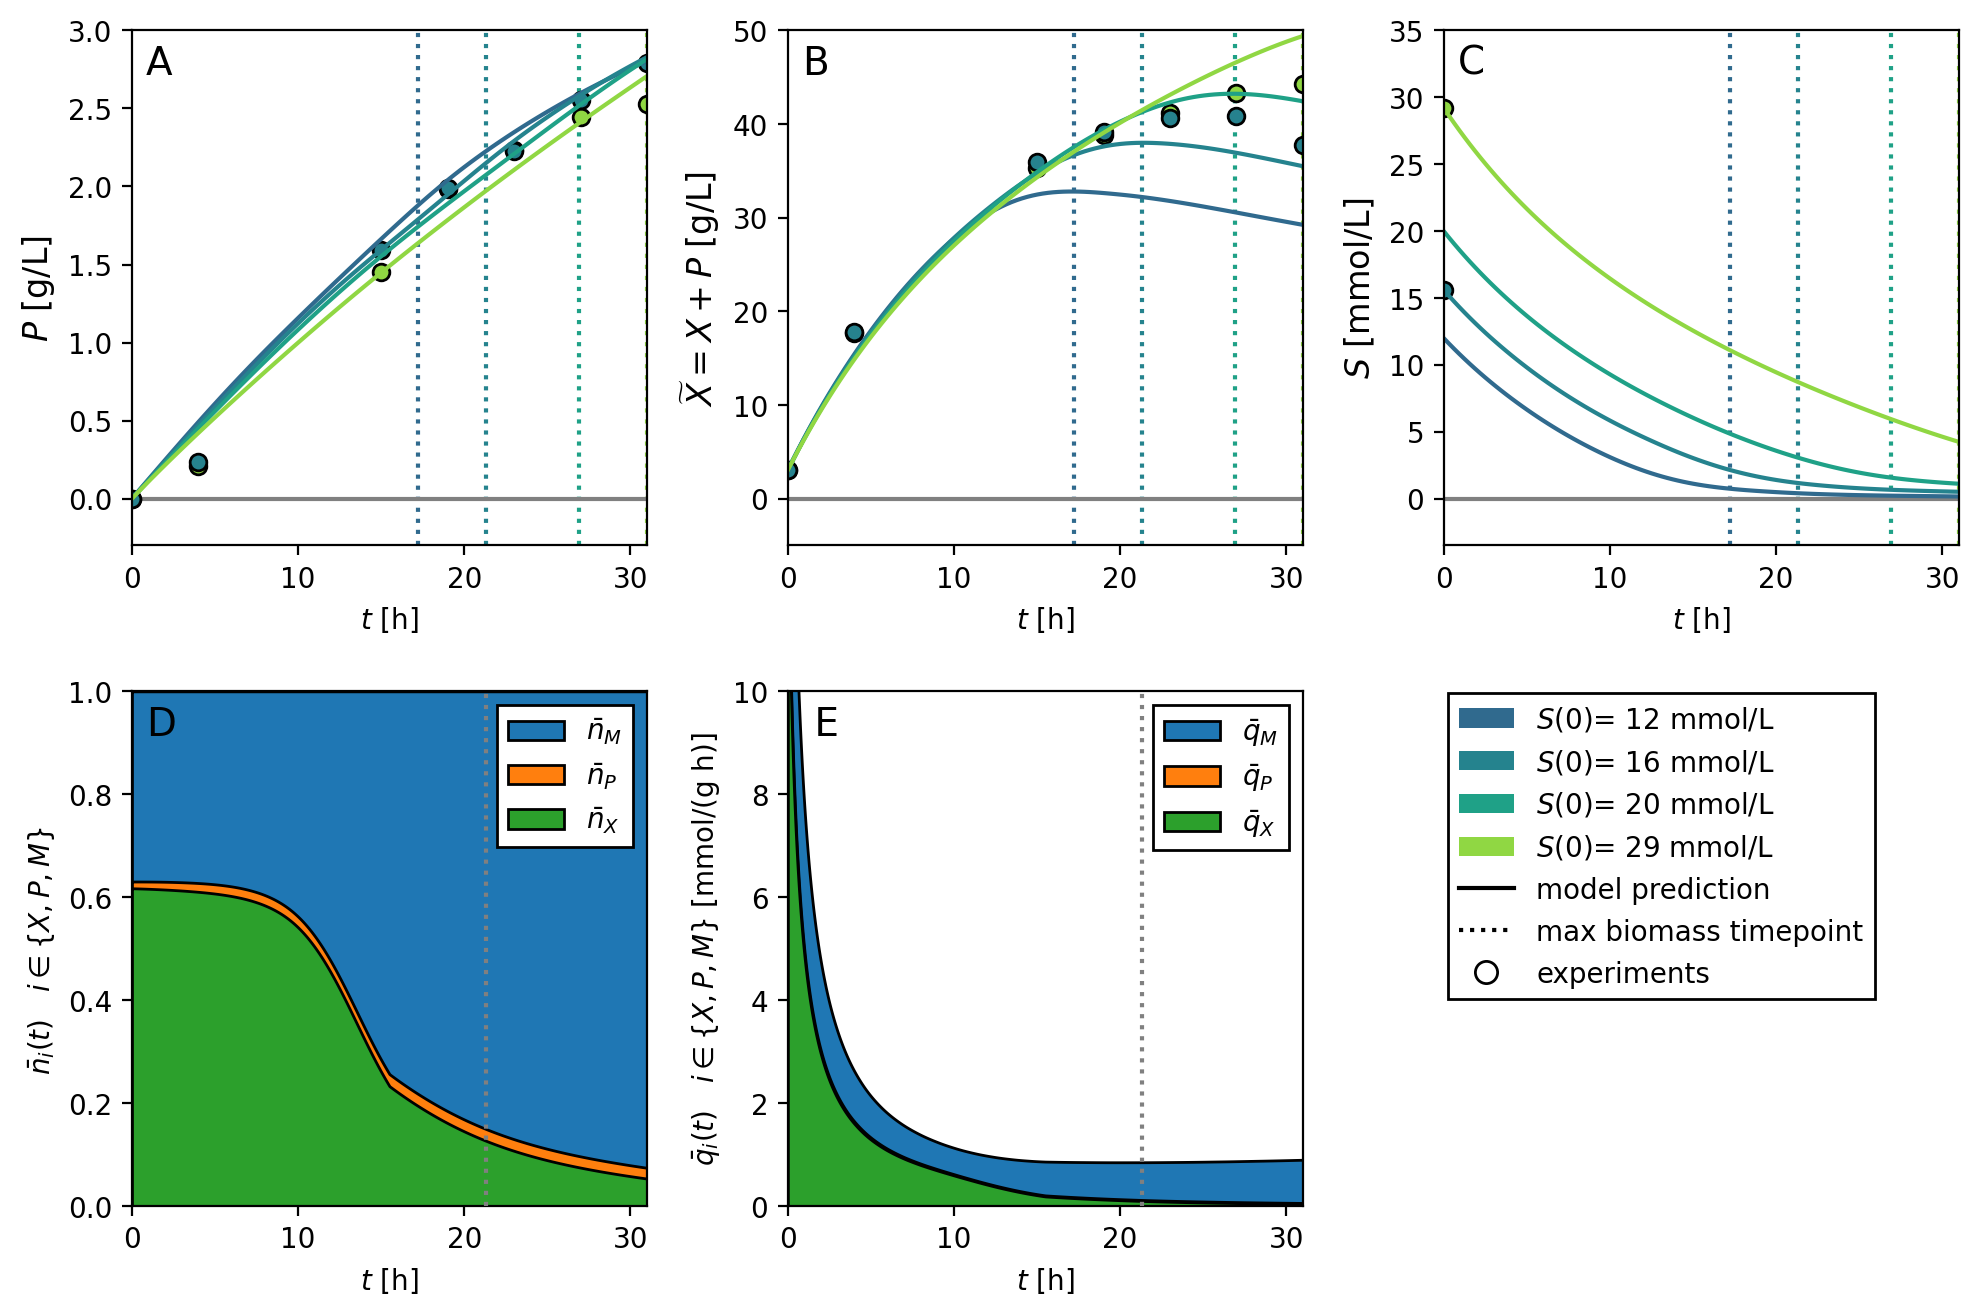

In [14]:
key = jax.random.PRNGKey(13)

SRfba_ENS = ENS_models["SLIM_03C"]
SRfba_TMP = SRfba_ENS.models[0]

NOfba_ENS = ENS_models["SLIM_03A"]
NOfba_TMP = NOfba_ENS.models[0]

def get_color(x):
    return mpl.colormaps["viridis"](x/35)

# Changed figsize from (5,8) to (8,5) for horizontal layout
fig = plt.figure(dpi=200, figsize=(10,8))

# Changed from 3x2 to 2x3 layout
ax1a = plt.subplot(231,box_aspect=1)  # row 1, col 1
ax2a = plt.subplot(232,box_aspect=1)  # row 1, col 2  
ax3a = plt.subplot(233,box_aspect=1)  # row 1, col 3
ax1b = plt.subplot(234,box_aspect=1)  # row 2, col 1
ax2b = plt.subplot(235,box_aspect=1)  # row 2, col 2
ax3b = plt.subplot(236,box_aspect=1)  # row 2, col 3

# FIRST ROW (FBA-Hyb)
adds = np.array([6,7.8,10,14.6])*2
j = 0
for l, add in enumerate(adds):
    data_ = [_[j:j+1] for _ in EXP_DATA]
    data_[5] = data_[5].at[0, 0, -1].set(add)  # subtract 10
    YT, yy_pred = AF.parse_data_to_model(SRfba_ENS, data_,key,timepoints=100)
    label = r"SO$_4^{2-}$ ="+f" {data_[5][0,0,-1]:.0f} mmol/L"
    color = get_color(add)

    YY_pred = SRfba_ENS.models[0].HYB.SCL_yy.unscale(yy_pred[0,:,:4]) 
    ax3a.plot(YT[0],yy_pred[0,:,-1],color=color)
    ax2a.plot(YT[0],YY_pred[:,2]   ,color=color)
    ax1a.plot(YT[0],YY_pred[:,1]   ,color=color)

    for ax in [ax1a,ax2a,ax3a]:
        ax.axvline(YT[0][np.argmax(YY_pred[:,2])], color=color, linestyle=":", zorder=-1)
    if np.isclose(add,7.8*2):
        ax2b.axvline(YT[0][np.argmax(YY_pred[:,2])], color="grey", linestyle=":", zorder=5)
        ax1b.axvline(YT[0][np.argmax(YY_pred[:,2])], color="grey", linestyle=":", zorder=5)


for axA, axB, lb, ub in zip([ax1a,ax2a,ax3a],[ax1b,ax2b,ax3b],[-3/10,-50/10,-35/10],[3,50,35]):
    axA.set_ylim(lb,ub)
    # axB.set_ylim(lb,ub)
    axA.axhline( 0,color="grey", linestyle="-", zorder=-1)
    axA.set_xlim(tt[0],tt[-1])
    axB.set_xlim(tt[0],tt[-1])
    axA.set_xlabel(r"$t$ [h]")
    axB.set_xlabel(r"$t$ [h]")

    # axB.axhline( 0,color="grey", linestyle="-", zorder=-1)

# EXPERIMENTAL DATA
plot_real_data = True
if plot_real_data:
    YT = EXP_DATA[1]
    YY_TRUE = SRfba_ENS.models[0].HYB.SCL_yy.unscale(EXP_DATA[0])

    YY_CTRL = np.mean(YY_TRUE[ctrl_idx,:,:],axis=0)
    YT_CTRL = np.mean(YT[ctrl_idx,:,0],axis=0)
    ax1a.scatter(YT_CTRL,YY_CTRL[:,1],edgecolor="k",color=get_color(14.606/.5))
    ax2a.scatter(YT_CTRL,YY_CTRL[:,2],edgecolor="k",color=get_color(14.606/.5))

    YY_SLIM = np.mean(YY_TRUE[slim_idx,:,:],axis=0)
    YT_SLIM = np.mean(YT[slim_idx,:,0],axis=0)
    ax1a.scatter(YT_SLIM,YY_SLIM[:,1],edgecolor="k",color=get_color(7.7899/.5))
    ax2a.scatter(YT_SLIM,YY_SLIM[:,2],edgecolor="k",color=get_color(7.7899/.5))

# ax1a.set_ylabel("FBA-Hyb",fontsize=14)
titles = [r"$P$ [g/L]",r"$\widetilde{X}=X+P$ [g/L]",r"$S$ [mmol/L]"]
for ax,title in zip([ax1a,ax2a,ax3a],titles):
    ax.set_ylabel(title,fontsize=12)

# initial sulfate points
for s0 in [7.8, 14.6]:
    ax3a.scatter(0,s0/.5,edgecolor="k",color=get_color(s0/.5))


# SUBPANEL N
ax1b.fill_between(tt,n[:,2]+n[:,0]+n[:,1],label=r"$\bar{n}_M$",edgecolor="k")
ax1b.fill_between(tt,n[:,1]+n[:,0],label=r"$\bar{n}_P$",edgecolor="k")
ax1b.fill_between(tt,n[:,0],label=r"$\bar{n}_X$",edgecolor="k")
ax1b.set_ylim(0,1)
ax1b.set_ylabel(r"$\bar{n}_i(t) \quad i \in \{X, P, M\}$ ")
ax1b.legend(fancybox=False,framealpha=1,edgecolor="k",loc="upper right",ncol=1,fontsize=10)

# SUBPANEL Q
ax2b.fill_between(tt,q[:,2]+q[:,0]+q[:,1],label=r"$\bar{q}_M$",edgecolor="k")
ax2b.fill_between(tt,q[:,1]+q[:,0],label=r"$\bar{q}_P$",edgecolor="k")
ax2b.fill_between(tt,q[:,0],label=r"$\bar{q}_X$",edgecolor="k")
ax2b.set_ylabel(r"$\bar{q}_i(t) \quad i \in \{X, P, M\}$ [mmol/(g h)]")
ax2b.set_ylim(0,10)
ax2b.legend(fancybox=False,framealpha=1,edgecolor="k",loc="upper right",ncol=1,fontsize=10)

plot_legend = True
if plot_legend:
    ax3b.set_axis_off()
    # Create legend with 2 columns - all elements listed sequentially
    legend_elements = []

    # Add SO4 concentrations
    for add in adds:
        color = get_color(add)
        label = r"$S(0)$= " + f"{add:.0f} mmol/L"
        legend_elements.append(plt.bar([0], [0], color=color, linewidth=5, label=label))

    # Add line style explanations
    # legend_elements.append(plt.Line2D([0], [0], color='white', linestyle='-', label=''))
    legend_elements.append(plt.Line2D([0], [0], color='black', linestyle='-', label='model prediction'))
    # legend_elements.append(plt.Line2D([0], [0], color='black', linestyle='-.', label='post-hoc calculation'))
    legend_elements.append(plt.Line2D([0], [0], color='black', linestyle=':', label='max biomass timepoint'))

    # Add scatter point explanations
    legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor="w", 
                                    markeredgecolor='k', markersize=8, label= "experiments", linestyle='None'))

    # Place legend at the bottom of the figure with 2 columns
    fig.tight_layout()
    legend_x = ax3b.get_position().x0-.005
    legend_y = ax3b.get_position().y1+.0695
    fig.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(legend_x, legend_y), ncol=1, 
            frameon=True, fancybox=False, shadow=False, columnspacing=2.0,fontsize=10,framealpha=1,edgecolor="black")

import matplotlib.transforms as mtransforms
for name, ax in zip(['A','B','C','D',' E','F'],[ax1a,ax2a,ax3a,ax1b,ax2b]):
    trans = mtransforms.ScaledTranslation(5/72, -5/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, name, transform=ax.transAxes + trans,
    fontsize=14, verticalalignment='top', fontfamily='sans',
    bbox=dict(facecolor='none', edgecolor='none', pad=3.0))

# Adjust layout to make room for legend
fig.tight_layout()

fig.align_ylabels([ax1a,ax1b])
fig.align_ylabels([ax2a,ax2b])
plt.subplots_adjust(bottom=0.1)
plt.show()

# Figer SLIM OPTIM only Std-Hyb

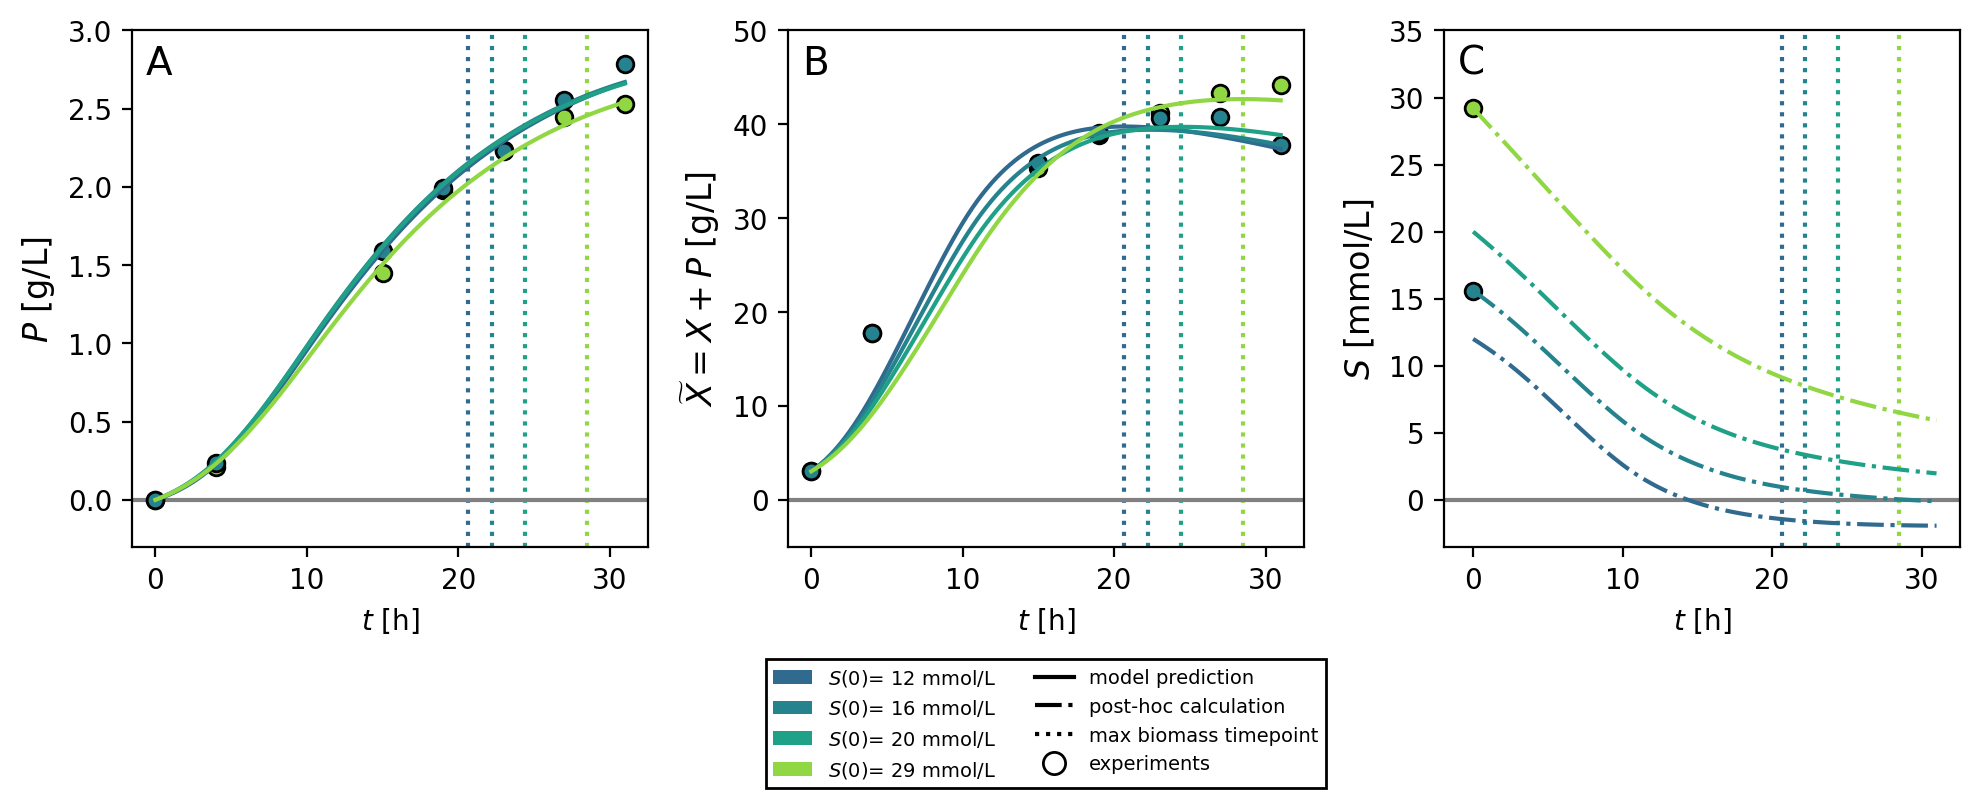

In [15]:
key = jax.random.PRNGKey(13)

SRfba_ENS = ENS_models["SLIM_03C"]
SRfba_TMP = SRfba_ENS.models[0]

NOfba_ENS = ENS_models["SLIM_03Ai"]
NOfba_TMP = NOfba_ENS.models[0]

def get_color(x):
    return mpl.colormaps["viridis"](x/35)

# Changed figsize from (5,8) to (8,5) for horizontal layout
fig = plt.figure(dpi=200, figsize=(10,5))

# Changed from 3x2 to 2x3 layout
ax1b = plt.subplot(131,box_aspect=1)  # row 1, col 1
ax2b = plt.subplot(132,box_aspect=1)  # row 1, col 2  
ax3b = plt.subplot(133,box_aspect=1)  # row 1, col 3

adds = np.array([6,7.8,10,14.6])*2
j = 0
for l, add in enumerate(adds):
    data_ = [_[j:j+1] for _ in EXP_DATA]
    data_[5] = data_[5].at[0, 0, -1].set(add)  # subtract 10
    YT, yy_pred = AF.parse_data_to_model(SRfba_ENS, data_,key,timepoints=100)
    label = r"SO$_4^{2-}$ ="+f" {data_[5][0,0,-1]:.0f} mmol/L"
    color = get_color(add)

    YY_pred = SRfba_ENS.models[0].HYB.SCL_yy.unscale(yy_pred[0,:,:4]) 

    for ax in [ax1a,ax2a,ax3a]:
        ax.axvline(YT[0][np.argmax(YY_pred[:,2])], color=color, linestyle=":", zorder=-1)

for l, add in enumerate(adds):
    data_ = [_[j:j+1] for _ in EXP_DATA]
    data_[5] = data_[5].at[0, 0, -1].set(add)
    YT, yy_pred = AF.parse_data_to_model(NOfba_ENS, data_,key,timepoints=100)
    label = r"SO$_4^{2-}$ ="+f" {data_[5][0,0,-1]:.0f} mmol/L"
    color = get_color(add)

    YY_pred = NOfba_ENS.models[0].HYB.SCL_yy.unscale(yy_pred[0,:,:4]) 
    XV = YY_pred[:,2]*YY_pred[:,3]
    PV = YY_pred[:,1]*YY_pred[:,3]
    # growth of Xr (active biomass, i.e., biomass minus pDNA)
    dXV = (XV-PV)-(XV[0]-PV[0])
    S_consumed = dXV*0.2518200000000 # mmol
    S_conc = (data_[5][0,0,-1]*YY_pred[0,3] - S_consumed)/YY_pred[:,3]
    ax3b.plot(YT[0],S_conc,color=color,linestyle="-.")

    ax2b.plot(YT[0],YY_pred[:,2]   ,color=color)
    ax1b.plot(YT[0],YY_pred[:,1]   ,color=color)
    
    ax3b.axvline(YT[0][np.argmax(YY_pred[:,2])], color=color, linestyle=":", zorder=-1)
    ax2b.axvline(YT[0][np.argmax(YY_pred[:,2])], color=color, linestyle=":", zorder=-1)
    ax1b.axvline(YT[0][np.argmax(YY_pred[:,2])], color=color, linestyle=":", zorder=-1)

for axA, axB, lb, ub in zip([ax1a,ax2a,ax3a],[ax1b,ax2b,ax3b],[-3/10,-50/10,-35/10],[3,50,35]):
    axA.set_ylim(lb,ub)
    axB.set_ylim(lb,ub)
    axA.axhline( 0,color="grey", linestyle="-", zorder=-1)
    axB.axhline( 0,color="grey", linestyle="-", zorder=-1)

plot_real_data = True
if plot_real_data:
    YT = EXP_DATA[1]
    YY_TRUE = SRfba_ENS.models[0].HYB.SCL_yy.unscale(EXP_DATA[0])

    YY_CTRL = np.mean(YY_TRUE[ctrl_idx,:,:],axis=0)
    YT_CTRL = np.mean(YT[ctrl_idx,:,0],axis=0)
    ax1a.scatter(YT_CTRL,YY_CTRL[:,1],edgecolor="k",color=get_color(14.606/.5))
    ax1b.scatter(YT_CTRL,YY_CTRL[:,1],edgecolor="k",color=get_color(14.606/.5))
    ax2a.scatter(YT_CTRL,YY_CTRL[:,2],edgecolor="k",color=get_color(14.606/.5))
    ax2b.scatter(YT_CTRL,YY_CTRL[:,2],edgecolor="k",color=get_color(14.606/.5))

    YY_SLIM = np.mean(YY_TRUE[slim_idx,:,:],axis=0)
    YT_SLIM = np.mean(YT[slim_idx,:,0],axis=0)
    ax1a.scatter(YT_SLIM,YY_SLIM[:,1],edgecolor="k",color=get_color(7.7899/.5))
    ax1b.scatter(YT_SLIM,YY_SLIM[:,1],edgecolor="k",color=get_color(7.7899/.5))
    ax2a.scatter(YT_SLIM,YY_SLIM[:,2],edgecolor="k",color=get_color(7.7899/.5))
    ax2b.scatter(YT_SLIM,YY_SLIM[:,2],edgecolor="k",color=get_color(7.7899/.5))

# ax1a.set_ylabel("FBA-Hyb",fontsize=14)
# ax1b.set_ylabel("Std-Hyb",fontsize=14)
titles = [r"$P$ [g/L]",r"$\widetilde{X}=X+P$ [g/L]",r"$S$ [mmol/L]"]
for ax,title in zip([ax1b,ax2b,ax3b],titles):
    ax.set_ylabel(title,fontsize=12)

ax2b.set_xlabel("$t$ [h]")
ax3b.set_xlabel("$t$ [h]")
ax1b.set_xlabel("$t$ [h]")

for s0 in [7.8, 14.6]:
    ax3b.scatter(0,s0/.5,edgecolor="k",color=get_color(s0/.5))
    ax3a.scatter(0,s0/.5,edgecolor="k",color=get_color(s0/.5))

plot_legend = True
if plot_legend:
    # Create legend with 2 columns - all elements listed sequentially
    legend_elements = []

    # Add SO4 concentrations
    for add in adds:
        color = get_color(add)
        label = r"$S(0)$= " + f"{add:.0f} mmol/L"
        legend_elements.append(plt.bar([0], [0], color=color, linewidth=5, label=label))

    # Add line style explanations
    # legend_elements.append(plt.Line2D([0], [0], color='white', linestyle='-', label=''))
    legend_elements.append(plt.Line2D([0], [0], color='black', linestyle='-', label='model prediction'))
    legend_elements.append(plt.Line2D([0], [0], color='black', linestyle='-.', label='post-hoc calculation'))
    legend_elements.append(plt.Line2D([0], [0], color='black', linestyle=':', label='max biomass timepoint'))

    # Add scatter point explanations
    legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor="w", 
                                    markeredgecolor='k', markersize=8, label= "experiments", linestyle='None'))

    # Place legend at the bottom of the figure with 2 columns
    fig.tight_layout()
    ax1_pos = ax1b.get_position()
    ax2_pos = ax3b.get_position()
    legend_x = (ax1_pos.x0 + ax2_pos.x1) / 2
    fig.legend(handles=legend_elements, loc="center", bbox_to_anchor=(legend_x, .1), ncol=2, 
            frameon=True, fancybox=False, shadow=False, columnspacing=2.0,fontsize=7,framealpha=1,edgecolor="black")

import matplotlib.transforms as mtransforms
for name, ax in zip(['A','B','C','D','E','F'],[ax1b,ax2b,ax3b]):
    trans = mtransforms.ScaledTranslation(5/72, -5/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, name, transform=ax.transAxes + trans,
    fontsize=14, verticalalignment='top', fontfamily='sans',
    bbox=dict(facecolor='none', edgecolor='none', pad=3.0))

# Adjust layout to make room for legend
fig.tight_layout()
# fig.align_labels()
plt.subplots_adjust(bottom=0.1)
plt.show()